# Match up everyone

In [65]:
# imports
from importlib import reload
#import earthaccess

import os
import numpy as np

import pandas
from matplotlib import pyplot as plt
import seaborn as sns

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.crs as ccrs
import cartopy
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

from sklearn.metrics.pairwise import haversine_distances

from shapely.geometry import Polygon, Point
from shapely.vectorized import contains
from shapely.ops import orient

from ocpy.utils import io as ocpy_io
from ocpy.utils import coords as ocpy_coords
from ocpy.pace import io as pace_io

from remote_sensing.plotting import globe
from remote_sensing.download import earthaccess as rs_ea

# locals
import grab_pace_granules
import argo
import gpolygons

# Load up BGC

In [2]:
reload(argo)
argo_pace = argo.load_argo()

In [3]:
argo_pace.head()

,cruise,filename,profile,lat,lon,time,solar_angle
261,1902304,1902304QC.nc,158,56.325,-18.987,2024-04-10 21:11:00.000001024+00:00,-8.083862
262,1902304,1902304QC.nc,159,56.290,-18.758,2024-04-20 21:24:00.000004608+00:00,-6.925605
263,1902304,1902304QC.nc,160,56.509,-18.912,2024-04-30 21:30:00.000003584+00:00,-4.744463
264,1902304,1902304QC.nc,161,57.344,-19.839,2024-05-10 20:40:00.000001024+00:00,4.443112
265,1902304,1902304QC.nc,163,57.463,-19.798,2024-05-30 20:25:00.000004608+00:00,9.799566


# Load PACE granules

In [4]:
reload(grab_pace_granules)
granules, pace = grab_pace_granules.load_from_json('PACE_50clouds.json')

In [5]:
pace.head()

,id,polygon,time,CC,url
0,PACE_OCI_L2_AOP_PACE_OCI.20240305T045359.L2.OC...,"POLYGON ((129.99634 19.95012, 105.26324 14.805...",2024-03-05 04:56:28.500000+00:00,49.5,https://obdaac-tea.earthdatacloud.nasa.gov/ob-...
1,PACE_OCI_L2_AOP_PACE_OCI.20240305T081040.L2.OC...,"POLYGON ((80.81132 19.9969, 56.07363 14.85543,...",2024-03-05 08:13:10+00:00,48.2,https://obdaac-tea.earthdatacloud.nasa.gov/ob-...
2,PACE_OCI_L2_AOP_PACE_OCI.20240305T112721.L2.OC...,"POLYGON ((31.63485 20.04028, 6.9071 14.89843, ...",2024-03-05 11:29:50.500000+00:00,42.7,https://obdaac-tea.earthdatacloud.nasa.gov/ob-...
3,PACE_OCI_L2_AOP_PACE_OCI.20240305T143902.L2.OC...,"POLYGON ((-14.32906 2.23116, -38.0179 -2.80614...",2024-03-05 14:41:31.500000+00:00,46.1,https://obdaac-tea.earthdatacloud.nasa.gov/ob-...
4,PACE_OCI_L2_AOP_PACE_OCI.20240305T162722.L2.OC...,"POLYGON ((-44.22893 37.98507, -73.20055 32.449...",2024-03-05 16:29:51.500000+00:00,48.9,https://obdaac-tea.earthdatacloud.nasa.gov/ob-...


## Loop over em

In [84]:
# too slow
'''
match_up = []
for ss in range(len(argo_pace)):
    iargo = argo_pace.iloc[ss]
    # In granule?
    point = Point(iargo.lon, iargo.lat)
    in_poly = [poly.contains(point) for poly in pace.polygon.values]
    in_poly = np.array(in_poly)
    # In time window?
    dt = pace.time - pandas.Timestamp(iargo.time)#, tz='UTC')
    good_dt = np.abs(dt) < pandas.Timedelta('1 day')
    # Ok for both?
    match_up.append(np.any(in_poly & good_dt))
'''

"\nmatch_up = []\nfor ss in range(len(argo_pace)):\n    iargo = argo_pace.iloc[ss]\n    # In granule?\n    point = Point(iargo.lon, iargo.lat)\n    in_poly = [poly.contains(point) for poly in pace.polygon.values]\n    in_poly = np.array(in_poly)\n    # In time window?\n    dt = pace.time - pandas.Timestamp(iargo.time)#, tz='UTC')\n    good_dt = np.abs(dt) < pandas.Timedelta('1 day')\n    # Ok for both?\n    match_up.append(np.any(in_poly & good_dt))\n"

----

## Inside?

In [6]:
all_inside = []
for ss in range(len(pace)):
    inside = contains(pace.polygon.values[ss], argo_pace.lon, argo_pace.lat)
    all_inside.append(np.array(inside))
all_inside = np.array(all_inside)

## Ok time?

In [7]:
ok_times = []
for ss in range(len(pace)):
    dt = pandas.Timestamp(pace.iloc[ss].time) - argo_pace.time
    good_dt = np.abs(dt) < pandas.Timedelta('1 day')
    ok_times.append(np.array(good_dt))
ok_times = np.array(ok_times)

In [8]:
ok_times.shape

(4654, 5954)

In [9]:
match = all_inside & ok_times

In [10]:
good_argo = np.any(match, axis=0)

In [11]:
np.sum(good_argo)

np.int64(812)

In [12]:
good_argo.size

5954

## Check one

In [68]:
iargo = np.where(good_argo)[0][50]
iargo

np.int64(451)

In [69]:
ipace = np.where(match[:,iargo])[0][0]
ipace

np.int64(1914)

In [70]:
pace.iloc[ipace]

id         PACE_OCI_L2_AOP_PACE_OCI.20240827T161621.L2.OC...
polygon    POLYGON ((-41.62914 35.80624, -69.75741 30.359...
time                        2024-08-27 16:18:50.500000+00:00
CC                                                      50.0
url        https://obdaac-tea.earthdatacloud.nasa.gov/ob-...
Name: 1914, dtype: object

## Plot

In [71]:
granules[pace.iloc[1000].id]['umm']['SpatialExtent']

{'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Latitude': 66.61763,
        'Longitude': 102.71387},
       {'Latitude': 58.51841, 'Longitude': 50.89997},
       {'Latitude': 42.94431, 'Longitude': 66.98865},
       {'Latitude': 48.98683, 'Longitude': 101.02406},
       {'Latitude': 66.61763, 'Longitude': 102.71387}]}}]}}}

In [72]:
spat = rs_ea.extract_spatial_extent(granules[pace.iloc[ipace].id])
spat

{'bounding_rectangles': [],
 'gpolygons': [{'boundary_points': [(-41.62914, 35.80624),
    (-69.75741, 30.35949),
    (-62.40452, 7.62659),
    (-38.4972, 12.62093),
    (-41.62914, 35.80624)],
   'exclusive_zones': []}],
 'points': [],
 'lines': []}

In [73]:
#reload(gpolygons)
#gpolygons.plot_spatial_extent(granules[pace.iloc[2971].id])
#plt.show()

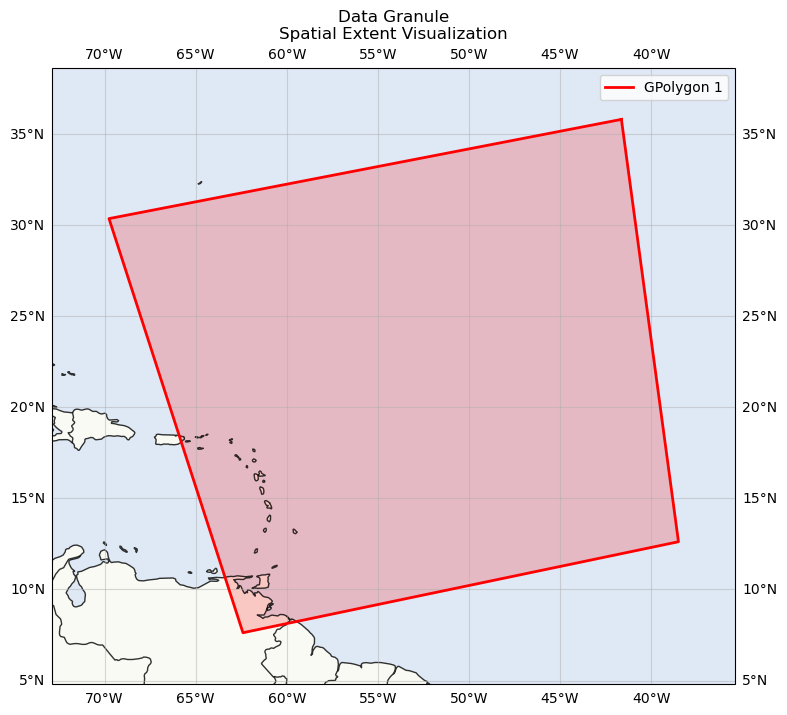

In [74]:
gpolygons.plot_spatial_extent(granules[pace.iloc[ipace].id])
plt.show()

In [75]:
def plot_Rrs(xds):
    fig = plt.figure(figsize=(10,6))
    
    # Create axes with Plate Carree projection
    ax = plt.axes(projection=ccrs.PlateCarree())
    
    # Select wavelength at 440nm
    chosen_wl = xds.Rrs.isel(wl=38)
    
    
    # Modify Rrs values
    bad = chosen_wl.data <= -32767
    chosen_wl.data[bad] =np.nan
    
    # Creates gridded colored rectangles
    # Plot using the axes we creates, geographic coordinates
    chosen_wl.plot.pcolormesh(x='longitude', y='latitude', ax=ax, 
                              transform=ccrs.PlateCarree(),
                             vmin=0.)
    
    # Add coastlines and land
    ax.coastlines()
    ax.add_feature(cfeature.LAND)
    
    gl = ax.gridlines(crs=ccrs.PlateCarree(), linewidth=1,
            color='black', alpha=0.5, linestyle=':', draw_labels=True)
    gl.xlabels_top = False
    gl.ylabels_left = True
    gl.ylabels_right=False
    gl.xlines = True
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'color': 'black'}
    gl.ylabel_style = {'color': 'black'}
    ax.set_title("Rrs at 440nm")
    plt.show()


In [76]:
pace.iloc[ipace].polygon.area

624.7135506896499

In [77]:
argo_pace.iloc[iargo]

cruise                                     1902384
filename                              1902384QC.nc
profile                                         95
lat                                          19.62
lon                                        -43.048
time           2024-08-26 19:41:00.000001024+00:00
solar_angle                              20.400915
Name: 1038, dtype: object

In [78]:
pace.iloc[ipace].polygon.contains(Point(argo_pace.iloc[iargo].lon, argo_pace.iloc[iargo].lat))

True

In [79]:
pace.iloc[ipace].url

'https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20240827T161621.L2.OC_AOP.V3_0.nc'

## Load it up

In [80]:
ifile = os.path.join(os.getenv('OS_COLOR'), 'PACE', 'Granules',
                     os.path.basename(pace.iloc[ipace].url))
xds, flags = pace_io.load_oci_l2(ifile)

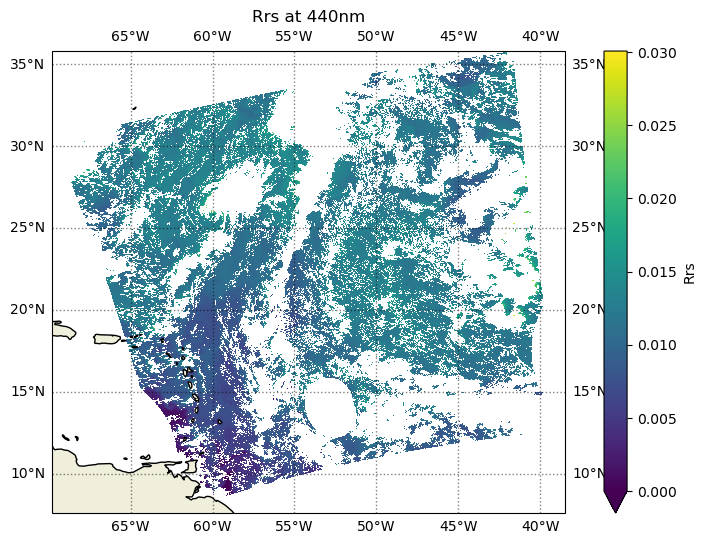

In [81]:
plot_Rrs(xds)

In [82]:
np.sum(flags == 0)

np.int64(2968)

In [83]:
Rrs_ok = xds.Rrs_unc.values[:,:,100] > 0.

In [84]:
np.sum(Rrs_ok) #/ xds.Rrs_unc.data.size

np.int64(1070684)

## Find closest non-zero

In [85]:
aargo = argo_pace.iloc[iargo]
aargo

cruise                                     1902384
filename                              1902384QC.nc
profile                                         95
lat                                          19.62
lon                                        -43.048
time           2024-08-26 19:41:00.000001024+00:00
solar_angle                              20.400915
Name: 1038, dtype: object

## Haversine

In [86]:
coords = np.stack((xds.latitude.values.flatten(), 
                   xds.longitude.values.flatten()), axis=1)
coords.shape

(2173848, 2)

In [87]:
reload(ocpy_coords)
d = ocpy_coords.distance_from_latlon((aargo.lat, aargo.lon), 
                                     coords)

In [88]:
d[Rrs_ok.flatten()].min()

np.float64(18.24004228820465)

In [56]:
d.shape

(2175120,)